# Trabalho Prático — Otimização Paralela de GEMM

**Disciplina:** Arquitetura de Computadores  
**Tema:** Processamento paralelo em CPU e GPU  
**Problema:** Multiplicação de matrizes densas — GEMM

Neste trabalho, você irá partir de uma implementação ingênua de multiplicação de matrizes e evoluir para versões otimizadas usando:

1. melhoria de localidade de memória;
2. blocagem/tiling;
3. vetorização SIMD;
4. paralelismo com OpenMP;
5. aceleração em GPU com CUDA;
6. análise completa de desempenho.

A operação calculada é:

$C = A \times B$


Para matrizes quadradas $N \times N$, o número aproximado de operações de ponto flutuante é:

$2N^3$

Logo, o desempenho em GFLOP/s é:

$
GFLOP/s = \frac{2N^3}{tempo \times 10^9}
$

# Trabalho Prático — Otimização Paralela de GEMM

**Disciplina:** Arquitetura de Computadores  
**Tema:** Processamento paralelo em CPU e GPU  
**Problema:** Multiplicação de matrizes densas — GEMM

Neste trabalho, você irá partir de uma implementação ingênua de multiplicação de matrizes e evoluir para versões otimizadas usando:

1. melhoria de localidade de memória;
2. blocagem/tiling;
3. vetorização SIMD;
4. paralelismo com OpenMP;
5. aceleração em GPU com CUDA;
6. análise completa de desempenho.

A operação calculada é:

$C = A \times B$


Para matrizes quadradas $N \times N$, o número aproximado de operações de ponto flutuante é:

$2N^3$

Logo, o desempenho em GFLOP/s é:

$
GFLOP/s = \frac{2N^3}{tempo \times 10^9}
$

## Entregáveis

Ao final, cada grupo deve entregar:

1. Este notebook preenchido com os resultados em PDF como anexo junto ao relatório.
2. Relatório em PDF contendo:
   - Metodologia experimental;
   - Tabelas de tempo;
   - Gráficos de desempenho;
   - Cálculo de GFLOP/s, speedup e eficiência;
   - Discussão dos resultados;
   - Conclusão crítica.

## Regras

- Não usar BLAS, cuBLAS, Eigen ou bibliotecas equivalentes na parte principal.
- Cada experimento deve ser executado pelo menos 5 vezes.
- Use a média dos tempos.
- Valide todas as versões comparando com a versão sequencial de referência.
- Bibliotecas prontas podem ser usadas apenas como comparação bônus.
- Use o colab para execução em GPU, mas para os testes CPU tente usar sua máquina devido o colab não oferecer mais de 2 nucleos de CPU.

# Parte 0 — Configuração do ambiente

Execute as células abaixo para verificar a CPU, a GPU e os compiladores disponíveis no Colab.

> Para usar CUDA, ative GPU em:  
> **Ambiente de execução → Alterar tipo de ambiente de execução → GPU**.

In [ ]:
!lscpu | head -n 30

Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           46 bits physical, 48 bits virtual
Byte Order:                              Little Endian
CPU(s):                                  2
On-line CPU(s) list:                     0,1
Vendor ID:                               GenuineIntel
Model name:                              Intel(R) Xeon(R) CPU @ 2.00GHz
CPU family:                              6
Model:                                   85
Thread(s) per core:                      2
Core(s) per socket:                      1
Socket(s):                               1
Stepping:                                3
BogoMIPS:                                4000.31
Flags:                                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ss ht syscall nx pdpe1gb rdtscp lm constant_tsc rep_good nopl xtopology nonstop_tsc cpuid tsc_known_freq 

In [ ]:
!nvidia-smi || true

Tue Jun 16 09:49:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!gcc --version | head -n 1
!nvcc --version | tail -n 4 || true

gcc (Ubuntu 11.4.0-1ubuntu1~22.04.3) 11.4.0
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


# Parte 1 — Código C base

A próxima célula cria um programa em C contendo várias versões de GEMM em CPU:

- `naive`: implementação ingênua;
- `transposed`: usa a matriz B transposta;
- `blocked`: usa blocagem/tiling;
- `openmp`: usa OpenMP;
- `blocked_openmp`: combina blocagem com OpenMP.

O programa também mede tempo, calcula GFLOP/s e valida o resultado.

Nesta etapa você deve implementar apenas as funções marcadas com **TODO**.
Caso necessário crie funções auxiliares, porém não mude as assinaturas das funções.

In [ ]:
%%writefile gemm_cpu.c

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>
#include <omp.h>

#ifndef ALIGNMENT
#define ALIGNMENT 64
#endif

static double now_seconds() {
    struct timespec ts;
    clock_gettime(CLOCK_MONOTONIC, &ts);
    return ts.tv_sec + ts.tv_nsec * 1e-9;
}

static float rand_float() {
    return (float)rand() / (float)RAND_MAX;
}

static void fill_matrix(int N, float *M) {
    for (int i = 0; i < N*N; i++) {
        M[i] = rand_float();
    }
}

static void zero_matrix(int N, float *M) {
    memset(M, 0, sizeof(float) * N * N);
}

static double max_abs_error(int N, const float *A, const float *B) {
    double err = 0.0;
    for (int i = 0; i < N*N; i++) {
        double e = fabs((double)A[i] - (double)B[i]);
        if (e > err) err = e;
    }
    return err;
}

/**
 * @brief Implementação ingênua de Multiplicação Geral de Matrizes (GEMM).
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N.
 * Esta função assume que as matrizes estão linearizadas em arrays de uma
 * dimensão (1D) e armazenadas na ordem row-major.
 *
 * @param N Dimensão das matrizes quadradas (N x N).
 * @param A Ponteiro constante para a matriz de entrada A.
 * @param B Ponteiro constante para a matriz de entrada B.
 * @param C Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_naive(int N, const float *A, const float *B, float *C) {
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            float sum = 0.0f;
            for (int k = 0; k < N; ++k) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}

void transpose(int N, const float *B, float *BT) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            BT[j*N + i] = B[i*N + j];
        }
    }
}

/**
 * @brief Implementação de Multiplicação Geral de Matrizes (GEMM) com matriz B transposta.
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N,
 * onde a matriz B já foi previamente transposta (fornecida como BT).
 * O acesso contíguo à memória para ambas as matrizes no laço mais interno
 * melhora significativamente a localidade espacial (cache) em comparação com a
 * implementação ingênua.
 *
 * @param N  Dimensão das matrizes quadradas (N x N).
 * @param A  Ponteiro constante para a matriz de entrada A (ordem row-major).
 * @param BT Ponteiro constante para a matriz de entrada B transposta (ordem row-major).
 * @param C  Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_transposed(int N, const float *A, const float *BT, float *C) {
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            float sum = 0.0f;
            for (int k = 0; k < N; ++k) {
                /* Acesso contíguo para A: A[i][k] */
                /* Acesso contíguo para BT: BT[j][k] (que corresponde a B[k][j]) */
                sum += A[i * N + k] * BT[j * N + k];
            }
            C[i * N + j] = sum;
        }
    }
}

/**
 * @brief Implementação de Multiplicação Geral de Matrizes (GEMM) utilizando particionamento em blocos (Tiling).
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N.
 * A otimização por blocos melhora o aproveitamento da hierarquia de memória,
 * garantindo que os sub-blocos operados permaneçam no cache durante o cálculo.
 * A matriz C é inicializada com zeros no escopo da função para permitir a
 * acumulação dos produtos parciais.
 *
 * @param N  Dimensão das matrizes quadradas (N x N).
 * @param BS Tamanho do bloco (Block Size) em uma dimensão (BS x BS).
 * @param A  Ponteiro constante para a matriz de entrada A (ordem row-major).
 * @param B  Ponteiro constante para a matriz de entrada B (ordem row-major).
 * @param C  Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_blocked(int N, int BS, const float *A, const float *B, float *C) {
    /* Inicialização da matriz resultante com zeros para acumulação correta */
    for (int i = 0; i < N * N; ++i) {
        C[i] = 0.0f;
    }

    /* Laços externos iteram sobre as matrizes em incrementos de tamanho BS */
    for (int i0 = 0; i0 < N; i0 += BS) {
        for (int j0 = 0; j0 < N; j0 += BS) {
            for (int k0 = 0; k0 < N; k0 += BS) {

                /* Cálculo dos limites dos blocos para evitar ultrapassar a dimensão N */
                int i_max = (i0 + BS > N) ? N : i0 + BS;
                int j_max = (j0 + BS > N) ? N : j0 + BS;
                int k_max = (k0 + BS > N) ? N : k0 + BS;

                /* Laços internos (micro-kernel) realizam a multiplicação restrita ao bloco */
                for (int i = i0; i < i_max; ++i) {
                    for (int j = j0; j < j_max; ++j) {
                        float sum = 0.0f;
                        for (int k = k0; k < k_max; ++k) {
                            sum += A[i * N + k] * B[k * N + j];
                        }
                        C[i * N + j] += sum;
                    }
                }
            }
        }
    }
}

/**
 * @brief Implementação paralela de Multiplicação Geral de Matrizes (GEMM) utilizando OpenMP.
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N.
 * Utiliza diretivas de compilação do OpenMP para distribuir as iterações
 * do laço externo entre as threads disponíveis na CPU, acelerando o cálculo
 * através de paralelismo de memória compartilhada.
 *
 * @param N Dimensão das matrizes quadradas (N x N).
 * @param A Ponteiro constante para a matriz de entrada A (ordem row-major).
 * @param B Ponteiro constante para a matriz de entrada B (ordem row-major).
 * @param C Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_openmp(int N, const float *A, const float *B, float *C) {
    /* A diretiva 'parallel for' divide o laço 'i' entre as threads.
       Variáveis declaradas dentro do escopo do laço (j, k, sum) são
       automaticamente privadas para cada thread. */
    #pragma omp parallel for
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            float sum = 0.0f;
            for (int k = 0; k < N; ++k) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}

/**
 * @brief Implementação de Multiplicação Geral de Matrizes (GEMM) combinando blocagem (Tiling) e paralelismo (OpenMP).
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N.
 * Esta versão une a otimização de localidade de cache (particionamento em
 * blocos de tamanho BS) com a paralelização de memória compartilhada (OpenMP).
 * A carga de trabalho dos blocos independentes é distribuída entre as
 * threads de execução da CPU.
 *
 * @param N  Dimensão das matrizes quadradas (N x N).
 * @param BS Tamanho do bloco (Block Size) em uma dimensão (BS x BS).
 * @param A  Ponteiro constante para a matriz de entrada A (ordem row-major).
 * @param B  Ponteiro constante para a matriz de entrada B (ordem row-major).
 * @param C  Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_blocked_openmp(int N, int BS, const float *A, const float *B, float *C) {
    /* Paraleliza a inicialização da matriz resultante com zeros */
    #pragma omp parallel for
    for (int i = 0; i < N * N; ++i) {
        C[i] = 0.0f;
    }

    /* A cláusula collapse(2) combina os dois laços externos (i0 e j0) em um
       único espaço de iteração maior, melhorando a distribuição de carga
       (load balancing) entre as threads, especialmente se N/BS for pequeno. */
    #pragma omp parallel for collapse(2)
    for (int i0 = 0; i0 < N; i0 += BS) {
        for (int j0 = 0; j0 < N; j0 += BS) {

            /* O laço k0 deve permanecer sequencial dentro da tarefa de cada thread
               para acumular corretamente os produtos parciais do bloco (i0, j0) */
            for (int k0 = 0; k0 < N; k0 += BS) {

                int i_max = (i0 + BS > N) ? N : i0 + BS;
                int j_max = (j0 + BS > N) ? N : j0 + BS;
                int k_max = (k0 + BS > N) ? N : k0 + BS;

                /* Micro-kernel sequencial local da thread */
                for (int i = i0; i < i_max; ++i) {
                    for (int j = j0; j < j_max; ++j) {
                        float sum = 0.0f;
                        for (int k = k0; k < k_max; ++k) {
                            sum += A[i * N + k] * B[k * N + j];
                        }
                        /* Acumulação segura: como cada par (i0, j0) é exclusivo de uma
                           iteração paralela, nenhuma outra thread escreverá nesta área de C */
                        C[i * N + j] += sum;
                    }
                }
            }
        }
    }
}

static void usage(const char *prog) {
    printf("Usage: %s <version> <N> <repeats> [BS]\n", prog);
    printf("Versions: naive, transposed, blocked, openmp, blocked_openmp\n");
}

int main(int argc, char **argv) {
    if (argc < 4) {
        usage(argv[0]);
        return 1;
    }

    const char *version = argv[1];
    int N = atoi(argv[2]);
    int repeats = atoi(argv[3]);
    int BS = (argc >= 5) ? atoi(argv[4]) : 32;

    srand(0);

    float *A, *B, *BT, *C, *Cref;
    posix_memalign((void**)&A, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&B, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&BT, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&C, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&Cref, ALIGNMENT, sizeof(float)*N*N);

    fill_matrix(N, A);
    fill_matrix(N, B);
    zero_matrix(N, C);
    zero_matrix(N, Cref);

    // Referência para validação.
    // Para N grande, isto pode demorar. Ainda assim, é importante para corretude.
    gemm_naive(N, A, B, Cref);

    if (strcmp(version, "transposed") == 0) {
        transpose(N, B, BT);
    }

    double best = 1e30;
    double total = 0.0;

    for (int r = 0; r < repeats; r++) {
        zero_matrix(N, C);
        double t0 = now_seconds();

        if (strcmp(version, "naive") == 0) {
            gemm_naive(N, A, B, C);
        } else if (strcmp(version, "transposed") == 0) {
            gemm_transposed(N, A, BT, C);
        } else if (strcmp(version, "blocked") == 0) {
            gemm_blocked(N, BS, A, B, C);
        } else if (strcmp(version, "openmp") == 0) {
            gemm_openmp(N, A, B, C);
        } else if (strcmp(version, "blocked_openmp") == 0) {
            gemm_blocked_openmp(N, BS, A, B, C);
        } else {
            usage(argv[0]);
            return 1;
        }

        double t1 = now_seconds();
        double elapsed = t1 - t0;
        if (elapsed < best) best = elapsed;
        total += elapsed;
    }

    double avg = total / repeats;
    double gflops = (2.0 * N * N * N) / (avg * 1e9);
    double err = max_abs_error(N, C, Cref);

    printf("version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error\n");
    printf("%s,%d,%d,%d,%d,%.6f,%.6f,%.6f,%.8f\n",
           version, N, BS, omp_get_max_threads(), repeats, avg, best, gflops, err);

    free(A); free(B); free(BT); free(C); free(Cref);
    return 0;
}

Writing gemm_cpu.c


# Parte 2 — Compilação da versão CPU

A flag `-O3` ativa otimizações agressivas.  
A flag `-march=native` permite usar extensões específicas da CPU disponível.  
A flag `-fopenmp` habilita OpenMP.

A flag `-fopt-info-vec-optimized` pede ao compilador informações sobre vetorização automática.

In [ ]:
!gcc gemm_cpu.c -O3 -march=native -fopenmp -fopt-info-vec-optimized -o gemm_cpu 2> vec_report.txt
!cat vec_report.txt | head -n 40

gemm_cpu.c: In function ‘main’:
gemm_cpu.c:250:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  250 |     posix_memalign((void**)&A, ALIGNMENT, sizeof(float)*N*N);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
gemm_cpu.c:251:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  251 |     posix_memalign((void**)&B, ALIGNMENT, sizeof(float)*N*N);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
gemm_cpu.c:252:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  252 |     posix_memalign((void**)&BT, ALIGNMENT, sizeof(float)*N*N);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
gemm_cpu.c:253:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  253 |     posix_mem

# Parte 3 — Execução automatizada dos experimentos CPU

A próxima célula executa vários experimentos e salva os resultados em `cpu_results.csv`.

Ajuste os valores de `N`, `BS` e `threads` caso necessário.

In [ ]:
import subprocess
import pandas as pd
from io import StringIO

experiments = []
Ns = [128, 256, 512]
repeats = 5

for N in Ns:
    experiments.append(("naive", N, None, None))
    experiments.append(("transposed", N, None, None))
    for BS in [16, 32, 64]:
        experiments.append(("blocked", N, BS, None))
    for th in [1, 2, 4, 8]:
        experiments.append(("openmp", N, None, th))
        experiments.append(("blocked_openmp", N, 32, th))

rows = []
for version, N, BS, th in experiments:
    cmd = ["./gemm_cpu", version, str(N), str(repeats)]
    if BS is not None:
        cmd.append(str(BS))
    env = None
    if th is not None:
        env = {"OMP_NUM_THREADS": str(th)}
    result = subprocess.run(cmd, capture_output=True, text=True, env=env)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        continue
    lines = result.stdout.strip().splitlines()
    if len(lines) >= 2:
        df = pd.read_csv(StringIO("\n".join(lines[-2:])))
        rows.append(df)

cpu_results = pd.concat(rows, ignore_index=True)
cpu_results.to_csv("cpu_results.csv", index=False)
cpu_results

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
naive,128,32,2,5,0.002250,0.002181,1.864336,0.00000000

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
transposed,128,32,2,5,0.001919,0.001883,2.185330,0.00000763

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked,128,16,2,5,0.001765,0.001679,2.376006,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked,128,32,2,5,0.001781,0.001709,2.355621,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked,128,64,2,5,0.002008,0.001889,2.088739,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
openmp,128,32,1,5,0.002553,0.002481,1.642861,0.00000000

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked_openmp,128,32,1,5,0.001889,0.001800,2.219869,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
ope

,version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
0,naive,128,32,2,5,0.002250,0.002181,1.864336,0.000000
1,transposed,128,32,2,5,0.001919,0.001883,2.185330,0.000008
2,blocked,128,16,2,5,0.001765,0.001679,2.376006,0.000023
3,blocked,128,32,2,5,0.001781,0.001709,2.355621,0.000023
4,blocked,128,64,2,5,0.002008,0.001889,2.088739,0.000023
5,openmp,128,32,1,5,0.002553,0.002481,1.642861,0.000000
6,blocked_openmp,128,32,1,5,0.001889,0.001800,2.219869,0.000023
7,openmp,128,32,2,5,0.001561,0.001464,2.687183,0.000000
8,blocked_openmp,128,32,2,5,0.001382,0.001300,3.035855,0.000023
9,openmp,128,32,4,5,0.001569,0.001518,2.673449,0.000000


# Parte 4 — Gráficos CPU

Use os gráficos abaixo como ponto de partida. Você pode criar gráficos adicionais no relatório.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

cpu_results = pd.read_csv("cpu_results.csv")
cpu_results

,version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
0,naive,128,32,2,5,0.002250,0.002181,1.864336,0.000000
1,transposed,128,32,2,5,0.001919,0.001883,2.185330,0.000008
2,blocked,128,16,2,5,0.001765,0.001679,2.376006,0.000023
3,blocked,128,32,2,5,0.001781,0.001709,2.355621,0.000023
4,blocked,128,64,2,5,0.002008,0.001889,2.088739,0.000023
5,openmp,128,32,1,5,0.002553,0.002481,1.642861,0.000000
6,blocked_openmp,128,32,1,5,0.001889,0.001800,2.219869,0.000023
7,openmp,128,32,2,5,0.001561,0.001464,2.687183,0.000000
8,blocked_openmp,128,32,2,5,0.001382,0.001300,3.035855,0.000023
9,openmp,128,32,4,5,0.001569,0.001518,2.673449,0.000000


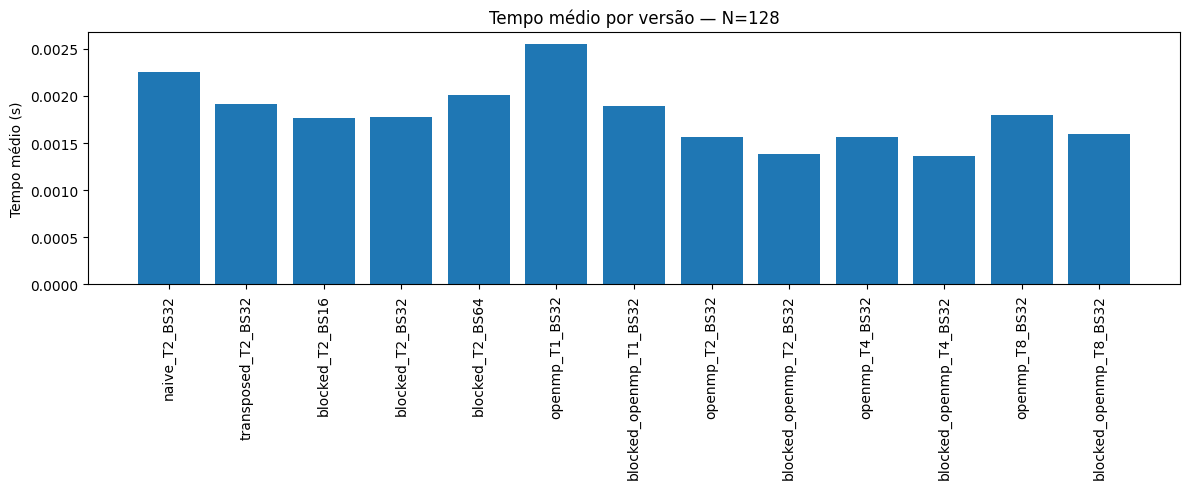

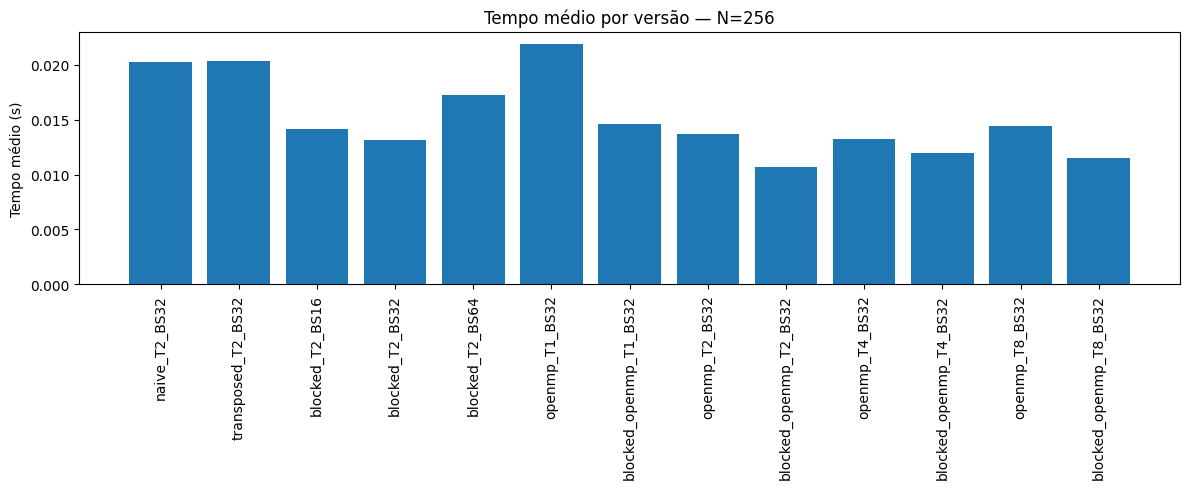

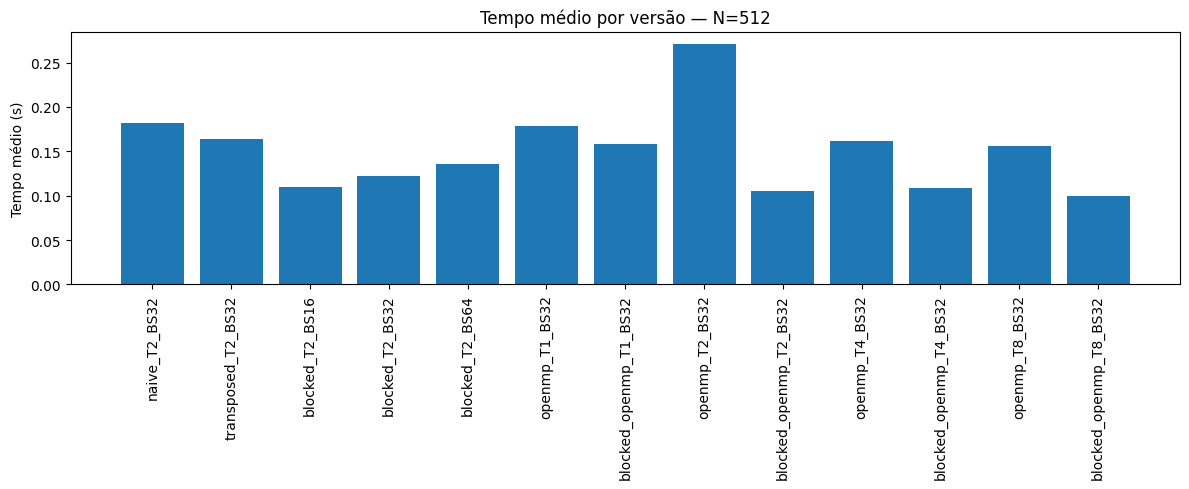

In [ ]:
for N in sorted(cpu_results["N"].unique()):
    df = cpu_results[cpu_results["N"] == N].copy()
    labels = df["version"] + "_T" + df["threads"].astype(str) + "_BS" + df["BS"].astype(str)
    plt.figure(figsize=(12, 5))
    plt.bar(labels, df["avg_time_s"])
    plt.xticks(rotation=90)
    plt.ylabel("Tempo médio (s)")
    plt.title(f"Tempo médio por versão — N={N}")
    plt.tight_layout()
    plt.show()

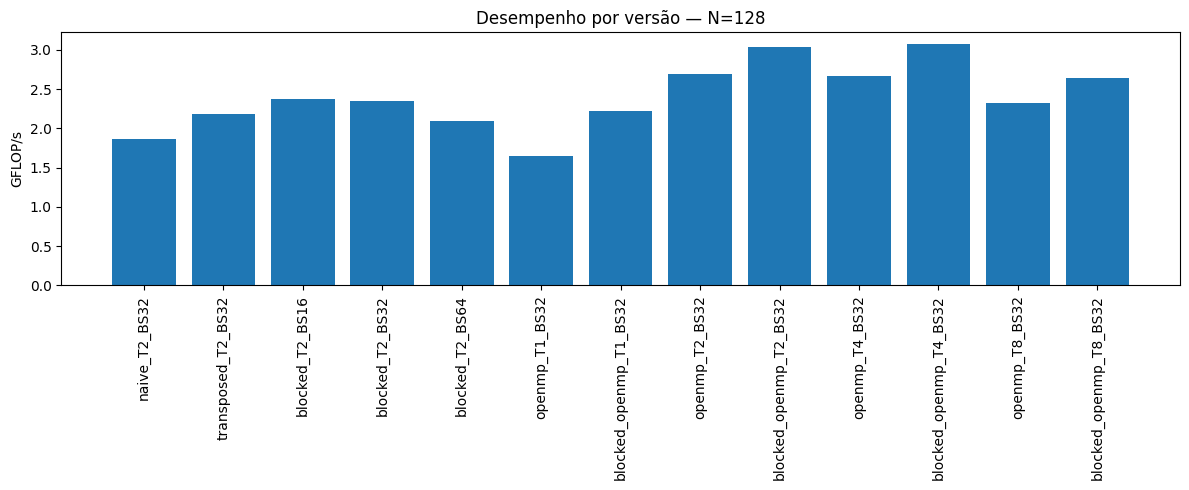

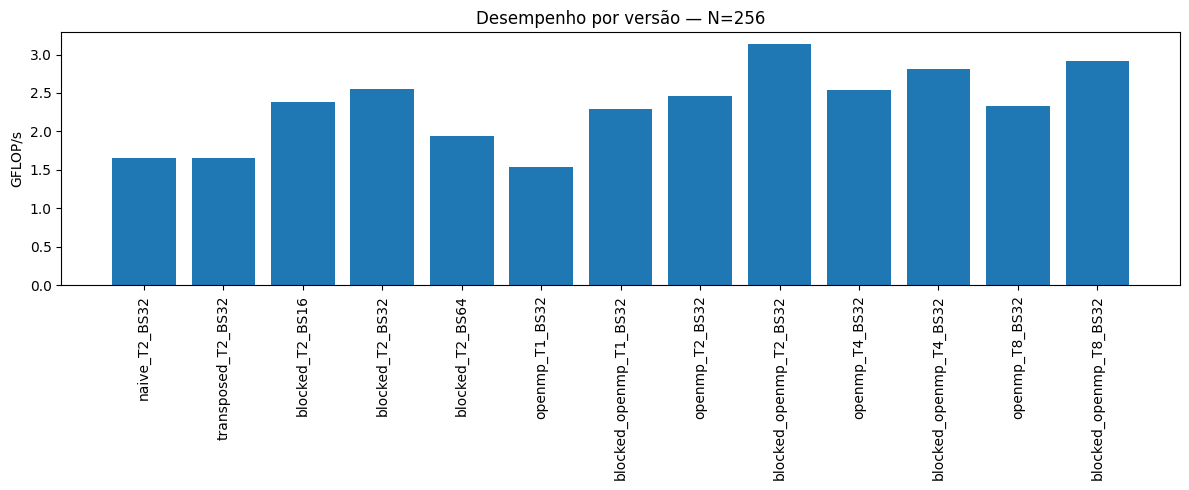

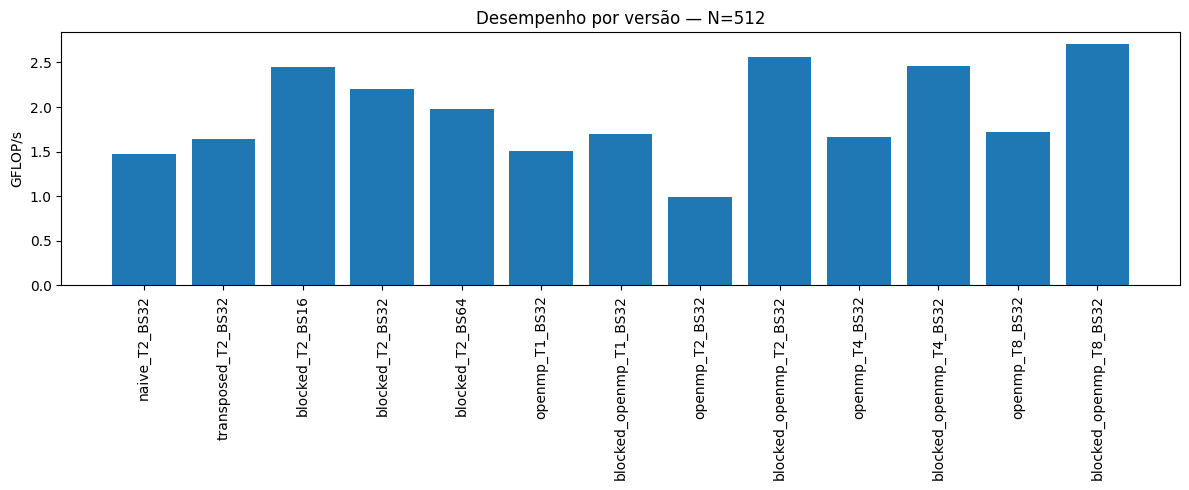

In [ ]:
for N in sorted(cpu_results["N"].unique()):
    df = cpu_results[cpu_results["N"] == N].copy()
    labels = df["version"] + "_T" + df["threads"].astype(str) + "_BS" + df["BS"].astype(str)
    plt.figure(figsize=(12, 5))
    plt.bar(labels, df["GFLOPS"])
    plt.xticks(rotation=90)
    plt.ylabel("GFLOP/s")
    plt.title(f"Desempenho por versão — N={N}")
    plt.tight_layout()
    plt.show()

# Parte 5 — Código CUDA

A próxima célula deve-se implementar o programa em CUDA com duas versões:

- `cuda_naive`: uma thread calcula um elemento de C;
- `cuda_tiled`: usa memória compartilhada para reduzir acessos à memória global.

O programa mede separadamente:

1. tempo de cópia host → device;
2. tempo do kernel;
3. tempo de cópia device → host;
4. tempo total.

In [ ]:
%%writefile gemm_cuda.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>

#define TILE 16

static float rand_float() {
    return (float)rand() / (float)RAND_MAX;
}

static void fill_matrix(int N, float *M) {
    for (int i = 0; i < N*N; i++) M[i] = rand_float();
}

static void gemm_cpu_ref(int N, const float *A, const float *B, float *C) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            float sum = 0.0f;
            for (int k = 0; k < N; k++) {
                sum += A[i*N + k] * B[k*N + j];
            }
            C[i*N + j] = sum;
        }
    }
}

static double max_abs_error(int N, const float *A, const float *B) {
    double err = 0.0;
    for (int i = 0; i < N*N; i++) {
        double e = fabs((double)A[i] - (double)B[i]);
        if (e > err) err = e;
    }
    return err;
}

/**
 * @brief Implementação ingênua (naive) da GEMM em CUDA.
 * * Cada thread processa estritamente um elemento da matriz de saída
 * calculando o produto escalar de uma linha por uma coluna.
 */
__global__ void gemm_cuda_naive(int N, const float *d_A, const float *d_B, float *d_C) {
    int row = blockIdx.y * blockDim.y + threadIdx.y;
    int col = blockIdx.x * blockDim.x + threadIdx.x;

    if (row < N && col < N) {
        float sum = 0.0f;
        for (int k = 0; k < N; k++) {
            sum += d_A[row * N + k] * d_B[k * N + col];
        }
        d_C[row * N + col] = sum;
    }
}

/**
 * @brief Multiplicação Geral de Matrizes utilizando blocagem (Tiling) em GPU.
 *
 * Utiliza a memória compartilhada para criar "tiles" (blocos) locais das matrizes
 * A e B. Isso reduz drasticamente as leituras redundantes na Memória Global.
 *
 * @param N Tamanho das dimensões das matrizes quadradas (N x N).
 * @param d_A Ponteiro para a matriz A de entrada (Memória do Device).
 * @param d_B Ponteiro para a matriz B de entrada (Memória do Device).
 * @param d_C Ponteiro para a matriz C resultante (Memória do Device).
 *
 * @note Configuração de Lançamento (Launch Config):
 * - Requer Grid 2D e Block 2D.
 * - O tamanho do bloco (BlockDim) deve ser obrigatoriamente configurado
 * como (TILE, TILE), em concordância com a alocação __shared__.
 */
__global__ void gemm_cuda_tiled(int N, const float *d_A, const float *d_B, float *d_C) {

    /** * @brief Caches locais do bloco para armazenar os tiles das matrizes.
     * Tamanho: (TILE x TILE) floats. Residem na Memória Compartilhada ultra-rápida.
     */
    __shared__ float s_A[TILE][TILE];
    __shared__ float s_B[TILE][TILE];

    // Índices locais da thread dentro do bloco (Tile)
    int tx = threadIdx.x;
    int ty = threadIdx.y;

    // Coordenadas globais da thread mapeadas para a matriz final
    int row = blockIdx.y * blockDim.y + ty;
    int col = blockIdx.x * blockDim.x + tx;

    // Acumulador local para o resultado
    float sum = 0.0f;

    // Calcula a quantidade de fases (tiles) necessárias para varrer a dimensão N
    int numTiles = (N + TILE - 1) / TILE;

    for (int p = 0; p < numTiles; p++) {

        // Fase de Carregamento para a Memória Compartilhada
        if (row < N && (p * TILE + tx) < N) {
            s_A[ty][tx] = d_A[row * N + (p * TILE + tx)];
        } else {
            s_A[ty][tx] = 0.0f;
        }

        if ((p * TILE + ty) < N && col < N) {
            s_B[ty][tx] = d_B[(p * TILE + ty) * N + col];
        } else {
            s_B[ty][tx] = 0.0f;
        }

        __syncthreads();

        // Fase de Multiplicação
        for (int k = 0; k < TILE; k++) {
            sum += s_A[ty][k] * s_B[k][tx];
        }

        __syncthreads();
    }

    // Fase de Escrita na Memória Global (Device)
    if (row < N && col < N) {
        d_C[row * N + col] = sum;
    }
}

static void check_cuda(cudaError_t err, const char *msg) {
    if (err != cudaSuccess) {
        fprintf(stderr, "CUDA error at %s: %s\n", msg, cudaGetErrorString(err));
        exit(1);
    }
}

int main(int argc, char **argv) {
    if (argc < 4) {
        printf("Usage: %s <naive|tiled> <N> <repeats>\n", argv[0]);
        return 1;
    }

    const char *version = argv[1];
    int N = atoi(argv[2]);
    int repeats = atoi(argv[3]);
    size_t bytes = sizeof(float) * N * N;

    srand(0);
    float *h_A = (float*)malloc(bytes);
    float *h_B = (float*)malloc(bytes);
    float *h_C = (float*)malloc(bytes);
    float *h_ref = (float*)malloc(bytes);

    fill_matrix(N, h_A);
    fill_matrix(N, h_B);

    gemm_cpu_ref(N, h_A, h_B, h_ref);

    float *d_A, *d_B, *d_C;
    check_cuda(cudaMalloc(&d_A, bytes), "cudaMalloc A");
    check_cuda(cudaMalloc(&d_B, bytes), "cudaMalloc B");
    check_cuda(cudaMalloc(&d_C, bytes), "cudaMalloc C");

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    float h2d_ms_total = 0.0f;
    float kernel_ms_total = 0.0f;
    float d2h_ms_total = 0.0f;

    dim3 block(TILE, TILE);
    dim3 grid((N + TILE - 1) / TILE, (N + TILE - 1) / TILE);

    for (int r = 0; r < repeats; r++) {
        float ms;

        cudaEventRecord(start);
        check_cuda(cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice), "copy A H2D");
        check_cuda(cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice), "copy B H2D");
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        h2d_ms_total += ms;

        cudaEventRecord(start);
        if (version[0] == 'n') {
            gemm_cuda_naive<<<grid, block>>>(N, d_A, d_B, d_C);
        } else {
            gemm_cuda_tiled<<<grid, block>>>(N, d_A, d_B, d_C);
        }
        check_cuda(cudaGetLastError(), "kernel launch");
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        kernel_ms_total += ms;

        cudaEventRecord(start);
        check_cuda(cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost), "copy C D2H");
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        d2h_ms_total += ms;
    }

    float h2d_ms = h2d_ms_total / repeats;
    float kernel_ms = kernel_ms_total / repeats;
    float d2h_ms = d2h_ms_total / repeats;
    float total_ms = h2d_ms + kernel_ms + d2h_ms;

    double kernel_gflops = (2.0 * N * N * N) / ((kernel_ms / 1000.0) * 1e9);
    double total_gflops = (2.0 * N * N * N) / ((total_ms / 1000.0) * 1e9);
    double err = max_abs_error(N, h_C, h_ref);

    printf("version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error\n");
    printf("cuda_%s,%d,%d,%.6f,%.6f,%.6f,%.6f,%.6f,%.6f,%.8f\n",
           version, N, repeats, h2d_ms, kernel_ms, d2h_ms, total_ms,
           kernel_gflops, total_gflops, err);

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_ref);
    return 0;
}

Overwriting gemm_cuda.cu


# Parte 6 — Compilação e execução CUDA

Caso esta célula falhe, verifique se o ambiente do Colab está com GPU ativada.

In [ ]:
!nvcc gemm_cuda.cu -O3 -o gemm_cuda

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


# Parte 7 — Experimentos automatizados em GPU

A próxima célula executa as versões CUDA para vários tamanhos de matriz e salva os resultados em `gpu_results.csv`.

In [ ]:
import subprocess
import pandas as pd
from io import StringIO

Ns = [128, 256, 512, 1024]
repeats = 5
rows = []

for N in Ns:
    for version in ["naive", "tiled"]:
        cmd = ["./gemm_cuda", version, str(N), str(repeats)]
        result = subprocess.run(cmd, capture_output=True, text=True)
        print(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            continue
        lines = result.stdout.strip().splitlines()
        if len(lines) >= 2:
            df = pd.read_csv(StringIO("\n".join(lines[-2:])))
            rows.append(df)

gpu_results = pd.concat(rows, ignore_index=True)
gpu_results.to_csv("gpu_results.csv", index=False)
gpu_results

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_naive,128,5,0.204045,23.906803,0.042573,24.153419,0.175444,0.173653,0.00000763

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_tiled,128,5,0.074010,0.053645,0.036550,0.164205,78.186592,25.543126,0.00000763

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_naive,256,5,0.164819,0.104794,0.113754,0.383366,320.195407,87.525749,0.00002289

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_tiled,256,5,0.164269,0.083962,0.120730,0.368960,399.640223,90.943280,0.00002289

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_naive,512,5,0.638771,0.489171,0.435558,1.563501,548.755668,171.688727,0.00004578

version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
cuda_tiled,512,5,0.

,version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
0,cuda_naive,128,5,0.204045,23.906803,0.042573,24.153419,0.175444,0.173653,0.000008
1,cuda_tiled,128,5,0.074010,0.053645,0.036550,0.164205,78.186592,25.543126,0.000008
2,cuda_naive,256,5,0.164819,0.104794,0.113754,0.383366,320.195407,87.525749,0.000023
3,cuda_tiled,256,5,0.164269,0.083962,0.120730,0.368960,399.640223,90.943280,0.000023
4,cuda_naive,512,5,0.638771,0.489171,0.435558,1.563501,548.755668,171.688727,0.000046
5,cuda_tiled,512,5,0.624429,0.322464,0.412224,1.359117,832.450956,197.507276,0.000046
6,cuda_naive,1024,5,2.057197,5.475872,1.502400,9.035469,392.171992,237.672625,0.000092
7,cuda_tiled,1024,5,2.013427,4.930848,1.493267,8.437543,435.520137,254.515286,0.000092


# Parte 8 — Gráficos GPU

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

gpu_results = pd.read_csv("gpu_results.csv")
gpu_results

,version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error
0,cuda_naive,128,5,0.204045,23.906803,0.042573,24.153419,0.175444,0.173653,0.000008
1,cuda_tiled,128,5,0.074010,0.053645,0.036550,0.164205,78.186592,25.543126,0.000008
2,cuda_naive,256,5,0.164819,0.104794,0.113754,0.383366,320.195407,87.525749,0.000023
3,cuda_tiled,256,5,0.164269,0.083962,0.120730,0.368960,399.640223,90.943280,0.000023
4,cuda_naive,512,5,0.638771,0.489171,0.435558,1.563501,548.755668,171.688727,0.000046
5,cuda_tiled,512,5,0.624429,0.322464,0.412224,1.359117,832.450956,197.507276,0.000046
6,cuda_naive,1024,5,2.057197,5.475872,1.502400,9.035469,392.171992,237.672625,0.000092
7,cuda_tiled,1024,5,2.013427,4.930848,1.493267,8.437543,435.520137,254.515286,0.000092


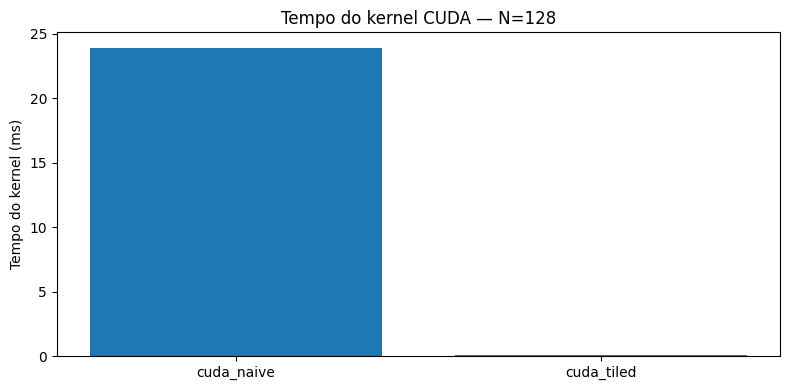

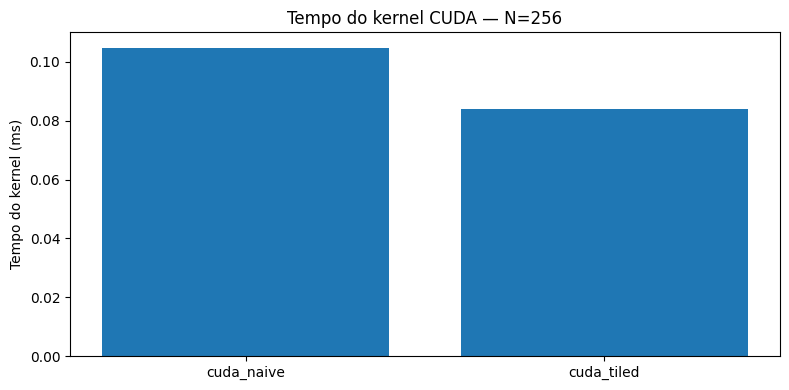

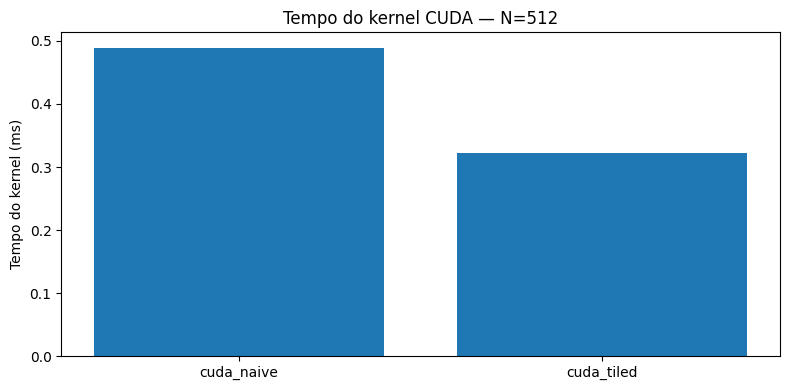

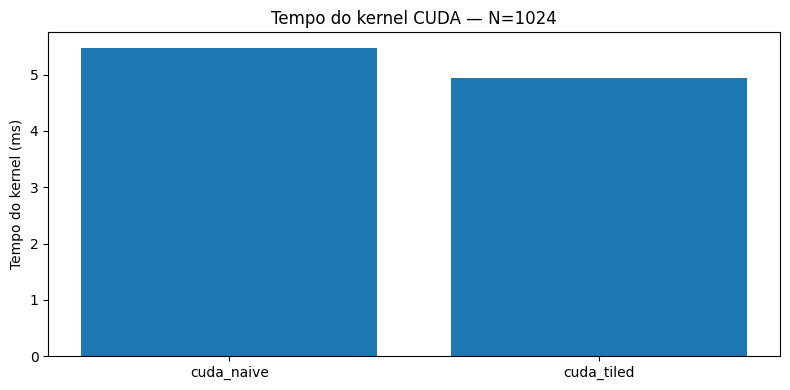

In [ ]:
for N in sorted(gpu_results["N"].unique()):
    df = gpu_results[gpu_results["N"] == N]
    plt.figure(figsize=(8, 4))
    plt.bar(df["version"], df["kernel_ms"])
    plt.ylabel("Tempo do kernel (ms)")
    plt.title(f"Tempo do kernel CUDA — N={N}")
    plt.tight_layout()
    plt.show()

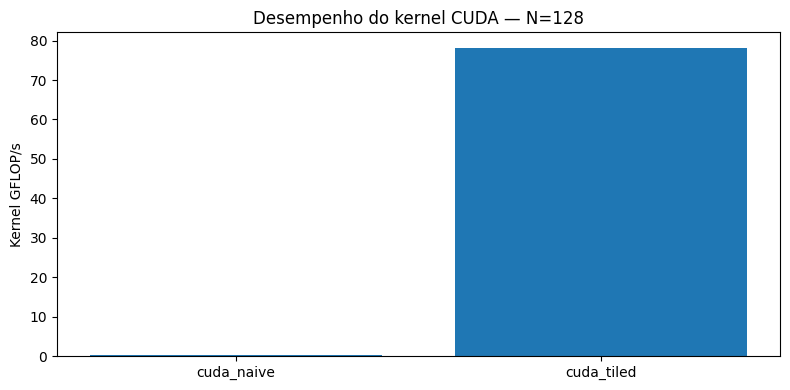

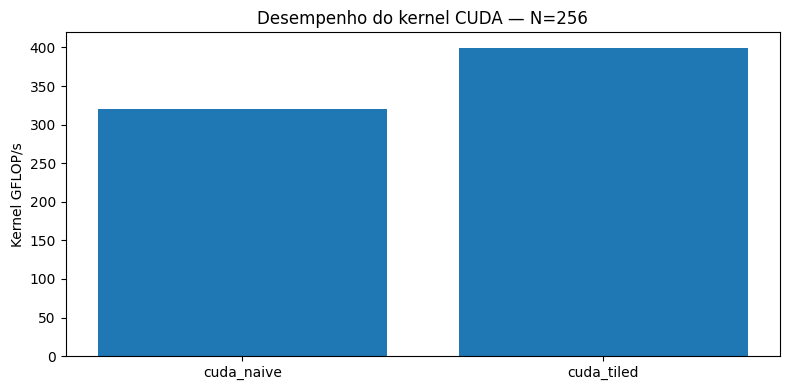

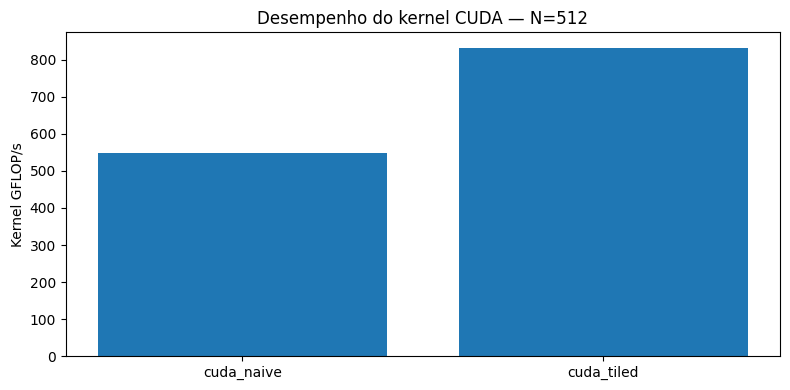

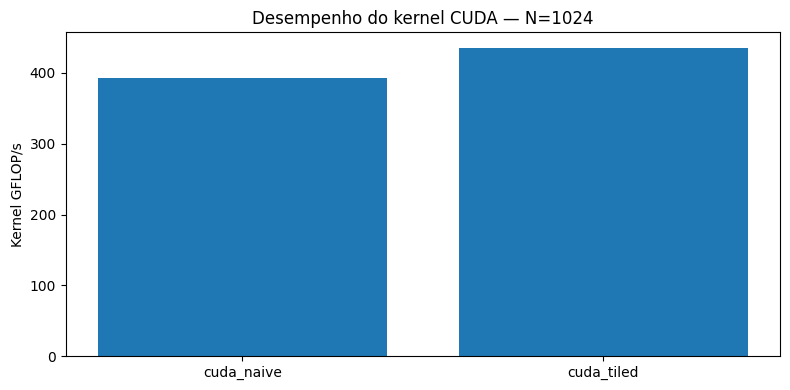

In [ ]:
for N in sorted(gpu_results["N"].unique()):
    df = gpu_results[gpu_results["N"] == N]
    plt.figure(figsize=(8, 4))
    plt.bar(df["version"], df["kernel_GFLOPS"])
    plt.ylabel("Kernel GFLOP/s")
    plt.title(f"Desempenho do kernel CUDA — N={N}")
    plt.tight_layout()
    plt.show()

# Parte 9 — Tabela final de comparação

Preencha a tabela final com os principais resultados obtidos.

| Versão | N | Tempo médio | GFLOP/s | Speedup | Eficiência | Observações |
|---|---:|---:|---:|---:|---:|---|
| CPU naive |  |  |  | 1,0 | 1,0 | Referência |
| CPU transposed |  |  |  |  |  | Localidade |
| CPU blocked |  |  |  |  |  | Cache |
| CPU OpenMP 2 threads |  |  |  |  |  | Threads |
| CPU OpenMP 4 threads |  |  |  |  |  | Threads |
| CUDA naive |  |  |  |  |  | Kernel simples |
| CUDA tiled |  |  |  |  |  | Memória compartilhada |

## Questões para discussão

Responda no relatório:

1. Por que a versão ingênua apresenta baixo desempenho?
2. O impacto da transposição de `B` foi significativo? Por quê?
3. Qual tamanho de bloco apresentou melhor desempenho? Por quê?
4. O compilador conseguiu vetorizar alguma parte do código? Use o relatório de vetorização como evidência.
5. O speedup com OpenMP foi próximo do ideal? Explique.
6. A eficiência diminuiu com mais threads? Por quê?
7. A GPU foi mais rápida considerando apenas o kernel?
8. A GPU foi mais rápida considerando o tempo total com cópias?
9. Qual foi a principal limitação observada: computação, memória, comunicação ou overhead?
10. Quais cuidados são necessários ao usar o Google Colab para avaliar desempenho?

# Parte 10 — Critérios de avaliação

## Implementação — 5 pontos

| Critério | Pontos |
|---|---:|
| Código sequencial correto e validação dos resultados | 1,0 |
| Otimização de localidade / transposição / blocagem | 1,0 |
| Análise de vetorização SIMD | 1,0 |
| Paralelização com OpenMP | 1,0 |
| Implementação CUDA com medição separada de cópia e kernel | 1,0 |

## Relatório — 5 pontos

| Critério | Pontos |
|---|---:|
| Metodologia experimental clara | 1,0 |
| Tabelas e gráficos bem apresentados | 1,0 |
| Cálculo correto de GFLOP/s, speedup e eficiência | 1,0 |
| Discussão técnica dos resultados | 1,5 |
| Conclusão crítica sobre limitações e trade-offs | 0,5 |

## Entregáveis

Ao final, cada grupo deve entregar:

1. Este notebook preenchido com os resultados em PDF como anexo junto ao relatório.
2. Relatório em PDF contendo:
   - Metodologia experimental;
   - Tabelas de tempo;
   - Gráficos de desempenho;
   - Cálculo de GFLOP/s, speedup e eficiência;
   - Discussão dos resultados;
   - Conclusão crítica.

## Regras

- Não usar BLAS, cuBLAS, Eigen ou bibliotecas equivalentes na parte principal.
- Cada experimento deve ser executado pelo menos 5 vezes.
- Use a média dos tempos.
- Valide todas as versões comparando com a versão sequencial de referência.
- Bibliotecas prontas podem ser usadas apenas como comparação bônus.
- Use o colab para execução em GPU, mas para os testes CPU tente usar sua máquina devido o colab não oferecer mais de 2 nucleos de CPU.

# Parte 0 — Configuração do ambiente

Execute as células abaixo para verificar a CPU, a GPU e os compiladores disponíveis no Colab.

> Para usar CUDA, ative GPU em:  
> **Ambiente de execução → Alterar tipo de ambiente de execução → GPU**.

In [1]:
!lscpu | head -n 30

Architecture:                            x86_64
CPU op-mode(s):                          32-bit, 64-bit
Address sizes:                           48 bits physical, 48 bits virtual
Byte Order:                              Little Endian
CPU(s):                                  8
On-line CPU(s) list:                     0-7
Vendor ID:                               AuthenticAMD
Model name:                              AMD Ryzen 3 5300G with Radeon Graphics
CPU family:                              25
Model:                                   80
Thread(s) per core:                      2
Core(s) per socket:                      4
Socket(s):                               1
Stepping:                                0
BogoMIPS:                                7985.00
Flags:                                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pge mca cmov pat pse36 clflush mmx fxsr sse sse2 ht syscall nx mmxext fxsr_opt pdpe1gb rdtscp lm rep_good nopl cpuid extd_apicid tsc_known_freq p

In [2]:
!nvidia-smi || true

/bin/bash: line 1: nvidia-smi: command not found


In [3]:
!gcc --version | head -n 1
!nvcc --version | tail -n 4 || true

gcc (Ubuntu 13.3.0-6ubuntu2~24.04.1) 13.3.0
/bin/bash: line 1: nvcc: command not found


# Parte 1 — Código C base

A próxima célula cria um programa em C contendo várias versões de GEMM em CPU:

- `naive`: implementação ingênua;
- `transposed`: usa a matriz B transposta;
- `blocked`: usa blocagem/tiling;
- `openmp`: usa OpenMP;
- `blocked_openmp`: combina blocagem com OpenMP.

O programa também mede tempo, calcula GFLOP/s e valida o resultado.

Nesta etapa você deve implementar apenas as funções marcadas com **TODO**.
Caso necessário crie funções auxiliares, porém não mude as assinaturas das funções.

In [4]:
%%writefile gemm_cpu.c

#include <stdio.h>
#include <stdlib.h>
#include <string.h>
#include <math.h>
#include <time.h>
#include <omp.h>

#ifndef ALIGNMENT
#define ALIGNMENT 64
#endif

static double now_seconds() {
    struct timespec ts;
    clock_gettime(CLOCK_MONOTONIC, &ts);
    return ts.tv_sec + ts.tv_nsec * 1e-9;
}

static float rand_float() {
    return (float)rand() / (float)RAND_MAX;
}

static void fill_matrix(int N, float *M) {
    for (int i = 0; i < N*N; i++) {
        M[i] = rand_float();
    }
}

static void zero_matrix(int N, float *M) {
    memset(M, 0, sizeof(float) * N * N);
}

static double max_abs_error(int N, const float *A, const float *B) {
    double err = 0.0;
    for (int i = 0; i < N*N; i++) {
        double e = fabs((double)A[i] - (double)B[i]);
        if (e > err) err = e;
    }
    return err;
}

/**
 * @brief Implementação ingênua de Multiplicação Geral de Matrizes (GEMM).
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N.
 * Esta função assume que as matrizes estão linearizadas em arrays de uma
 * dimensão (1D) e armazenadas na ordem row-major.
 *
 * @param N Dimensão das matrizes quadradas (N x N).
 * @param A Ponteiro constante para a matriz de entrada A.
 * @param B Ponteiro constante para a matriz de entrada B.
 * @param C Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_naive(int N, const float *A, const float *B, float *C) {
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            float sum = 0.0f;
            for (int k = 0; k < N; ++k) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}

void transpose(int N, const float *B, float *BT) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            BT[j*N + i] = B[i*N + j];
        }
    }
}

/**
 * @brief Implementação de Multiplicação Geral de Matrizes (GEMM) com matriz B transposta.
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N,
 * onde a matriz B já foi previamente transposta (fornecida como BT).
 * O acesso contíguo à memória para ambas as matrizes no laço mais interno
 * melhora significativamente a localidade espacial (cache) em comparação com a
 * implementação ingênua.
 *
 * @param N  Dimensão das matrizes quadradas (N x N).
 * @param A  Ponteiro constante para a matriz de entrada A (ordem row-major).
 * @param BT Ponteiro constante para a matriz de entrada B transposta (ordem row-major).
 * @param C  Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_transposed(int N, const float *A, const float *BT, float *C) {
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            float sum = 0.0f;
            for (int k = 0; k < N; ++k) {
                /* Acesso contíguo para A: A[i][k] */
                /* Acesso contíguo para BT: BT[j][k] (que corresponde a B[k][j]) */
                sum += A[i * N + k] * BT[j * N + k];
            }
            C[i * N + j] = sum;
        }
    }
}

/**
 * @brief Implementação de Multiplicação Geral de Matrizes (GEMM) utilizando particionamento em blocos (Tiling).
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N.
 * A otimização por blocos melhora o aproveitamento da hierarquia de memória,
 * garantindo que os sub-blocos operados permaneçam no cache durante o cálculo.
 * A matriz C é inicializada com zeros no escopo da função para permitir a
 * acumulação dos produtos parciais.
 *
 * @param N  Dimensão das matrizes quadradas (N x N).
 * @param BS Tamanho do bloco (Block Size) em uma dimensão (BS x BS).
 * @param A  Ponteiro constante para a matriz de entrada A (ordem row-major).
 * @param B  Ponteiro constante para a matriz de entrada B (ordem row-major).
 * @param C  Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_blocked(int N, int BS, const float *A, const float *B, float *C) {
    /* Inicialização da matriz resultante com zeros para acumulação correta */
    for (int i = 0; i < N * N; ++i) {
        C[i] = 0.0f;
    }

    /* Laços externos iteram sobre as matrizes em incrementos de tamanho BS */
    for (int i0 = 0; i0 < N; i0 += BS) {
        for (int j0 = 0; j0 < N; j0 += BS) {
            for (int k0 = 0; k0 < N; k0 += BS) {
                
                /* Cálculo dos limites dos blocos para evitar ultrapassar a dimensão N */
                int i_max = (i0 + BS > N) ? N : i0 + BS;
                int j_max = (j0 + BS > N) ? N : j0 + BS;
                int k_max = (k0 + BS > N) ? N : k0 + BS;

                /* Laços internos (micro-kernel) realizam a multiplicação restrita ao bloco */
                for (int i = i0; i < i_max; ++i) {
                    for (int j = j0; j < j_max; ++j) {
                        float sum = 0.0f;
                        for (int k = k0; k < k_max; ++k) {
                            sum += A[i * N + k] * B[k * N + j];
                        }
                        C[i * N + j] += sum;
                    }
                }
            }
        }
    }
}

/**
 * @brief Implementação paralela de Multiplicação Geral de Matrizes (GEMM) utilizando OpenMP.
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N.
 * Utiliza diretivas de compilação do OpenMP para distribuir as iterações
 * do laço externo entre as threads disponíveis na CPU, acelerando o cálculo
 * através de paralelismo de memória compartilhada.
 *
 * @param N Dimensão das matrizes quadradas (N x N).
 * @param A Ponteiro constante para a matriz de entrada A (ordem row-major).
 * @param B Ponteiro constante para a matriz de entrada B (ordem row-major).
 * @param C Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_openmp(int N, const float *A, const float *B, float *C) {
    /* A diretiva 'parallel for' divide o laço 'i' entre as threads. 
       Variáveis declaradas dentro do escopo do laço (j, k, sum) são 
       automaticamente privadas para cada thread. */
    #pragma omp parallel for
    for (int i = 0; i < N; ++i) {
        for (int j = 0; j < N; ++j) {
            float sum = 0.0f;
            for (int k = 0; k < N; ++k) {
                sum += A[i * N + k] * B[k * N + j];
            }
            C[i * N + j] = sum;
        }
    }
}

/**
 * @brief Implementação de Multiplicação Geral de Matrizes (GEMM) combinando blocagem (Tiling) e paralelismo (OpenMP).
 *
 * Calcula o produto de duas matrizes quadradas A e B de dimensões N x N.
 * Esta versão une a otimização de localidade de cache (particionamento em
 * blocos de tamanho BS) com a paralelização de memória compartilhada (OpenMP).
 * A carga de trabalho dos blocos independentes é distribuída entre as
 * threads de execução da CPU.
 *
 * @param N  Dimensão das matrizes quadradas (N x N).
 * @param BS Tamanho do bloco (Block Size) em uma dimensão (BS x BS).
 * @param A  Ponteiro constante para a matriz de entrada A (ordem row-major).
 * @param B  Ponteiro constante para a matriz de entrada B (ordem row-major).
 * @param C  Ponteiro para a matriz de saída C, que armazenará o resultado (A * B).
 */
void gemm_blocked_openmp(int N, int BS, const float *A, const float *B, float *C) {
    /* Paraleliza a inicialização da matriz resultante com zeros */
    #pragma omp parallel for
    for (int i = 0; i < N * N; ++i) {
        C[i] = 0.0f;
    }

    /* A cláusula collapse(2) combina os dois laços externos (i0 e j0) em um
       único espaço de iteração maior, melhorando a distribuição de carga
       (load balancing) entre as threads, especialmente se N/BS for pequeno. */
    #pragma omp parallel for collapse(2)
    for (int i0 = 0; i0 < N; i0 += BS) {
        for (int j0 = 0; j0 < N; j0 += BS) {
            
            /* O laço k0 deve permanecer sequencial dentro da tarefa de cada thread
               para acumular corretamente os produtos parciais do bloco (i0, j0) */
            for (int k0 = 0; k0 < N; k0 += BS) {
                
                int i_max = (i0 + BS > N) ? N : i0 + BS;
                int j_max = (j0 + BS > N) ? N : j0 + BS;
                int k_max = (k0 + BS > N) ? N : k0 + BS;

                /* Micro-kernel sequencial local da thread */
                for (int i = i0; i < i_max; ++i) {
                    for (int j = j0; j < j_max; ++j) {
                        float sum = 0.0f;
                        for (int k = k0; k < k_max; ++k) {
                            sum += A[i * N + k] * B[k * N + j];
                        }
                        /* Acumulação segura: como cada par (i0, j0) é exclusivo de uma
                           iteração paralela, nenhuma outra thread escreverá nesta área de C */
                        C[i * N + j] += sum;
                    }
                }
            }
        }
    }
}

static void usage(const char *prog) {
    printf("Usage: %s <version> <N> <repeats> [BS]\n", prog);
    printf("Versions: naive, transposed, blocked, openmp, blocked_openmp\n");
}

int main(int argc, char **argv) {
    if (argc < 4) {
        usage(argv[0]);
        return 1;
    }

    const char *version = argv[1];
    int N = atoi(argv[2]);
    int repeats = atoi(argv[3]);
    int BS = (argc >= 5) ? atoi(argv[4]) : 32;

    srand(0);

    float *A, *B, *BT, *C, *Cref;
    posix_memalign((void**)&A, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&B, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&BT, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&C, ALIGNMENT, sizeof(float)*N*N);
    posix_memalign((void**)&Cref, ALIGNMENT, sizeof(float)*N*N);

    fill_matrix(N, A);
    fill_matrix(N, B);
    zero_matrix(N, C);
    zero_matrix(N, Cref);

    // Referência para validação.
    // Para N grande, isto pode demorar. Ainda assim, é importante para corretude.
    gemm_naive(N, A, B, Cref);

    if (strcmp(version, "transposed") == 0) {
        transpose(N, B, BT);
    }

    double best = 1e30;
    double total = 0.0;

    for (int r = 0; r < repeats; r++) {
        zero_matrix(N, C);
        double t0 = now_seconds();

        if (strcmp(version, "naive") == 0) {
            gemm_naive(N, A, B, C);
        } else if (strcmp(version, "transposed") == 0) {
            gemm_transposed(N, A, BT, C);
        } else if (strcmp(version, "blocked") == 0) {
            gemm_blocked(N, BS, A, B, C);
        } else if (strcmp(version, "openmp") == 0) {
            gemm_openmp(N, A, B, C);
        } else if (strcmp(version, "blocked_openmp") == 0) {
            gemm_blocked_openmp(N, BS, A, B, C);
        } else {
            usage(argv[0]);
            return 1;
        }

        double t1 = now_seconds();
        double elapsed = t1 - t0;
        if (elapsed < best) best = elapsed;
        total += elapsed;
    }

    double avg = total / repeats;
    double gflops = (2.0 * N * N * N) / (avg * 1e9);
    double err = max_abs_error(N, C, Cref);

    printf("version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error\n");
    printf("%s,%d,%d,%d,%d,%.6f,%.6f,%.6f,%.8f\n",
           version, N, BS, omp_get_max_threads(), repeats, avg, best, gflops, err);

    free(A); free(B); free(BT); free(C); free(Cref);
    return 0;
}

Overwriting gemm_cpu.c


# Parte 2 — Compilação da versão CPU

A flag `-O3` ativa otimizações agressivas.  
A flag `-march=native` permite usar extensões específicas da CPU disponível.  
A flag `-fopenmp` habilita OpenMP.

A flag `-fopt-info-vec-optimized` pede ao compilador informações sobre vetorização automática.

In [5]:
!gcc gemm_cpu.c -O3 -march=native -fopenmp -fopt-info-vec-optimized -o gemm_cpu 2> vec_report.txt
!cat vec_report.txt | head -n 40

gemm_cpu.c: In function ‘main’:
gemm_cpu.c:250:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  250 |     posix_memalign((void**)&A, ALIGNMENT, sizeof(float)*N*N);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
gemm_cpu.c:251:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  251 |     posix_memalign((void**)&B, ALIGNMENT, sizeof(float)*N*N);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
gemm_cpu.c:252:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  252 |     posix_memalign((void**)&BT, ALIGNMENT, sizeof(float)*N*N);
      |     ^~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
gemm_cpu.c:253:5: warning: ignoring return value of ‘posix_memalign’ declared with attribute ‘warn_unused_result’ [-Wunused-result]
  253 |     posix_mem

# Parte 3 — Execução automatizada dos experimentos CPU

A próxima célula executa vários experimentos e salva os resultados em `cpu_results.csv`.

Ajuste os valores de `N`, `BS` e `threads` caso necessário.

In [6]:
import subprocess
import pandas as pd
from io import StringIO

experiments = []
Ns = [128, 256, 512]
repeats = 5

for N in Ns:
    experiments.append(("naive", N, None, None))
    experiments.append(("transposed", N, None, None))
    for BS in [16, 32, 64]:
        experiments.append(("blocked", N, BS, None))
    for th in [1, 2, 4, 8]:
        experiments.append(("openmp", N, None, th))
        experiments.append(("blocked_openmp", N, 32, th))

rows = []
for version, N, BS, th in experiments:
    cmd = ["./gemm_cpu", version, str(N), str(repeats)]
    if BS is not None:
        cmd.append(str(BS))
    env = None
    if th is not None:
        env = {"OMP_NUM_THREADS": str(th)}
    result = subprocess.run(cmd, capture_output=True, text=True, env=env)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        continue
    lines = result.stdout.strip().splitlines()
    if len(lines) >= 2:
        df = pd.read_csv(StringIO("\n".join(lines[-2:])))
        rows.append(df)

cpu_results = pd.concat(rows, ignore_index=True)
cpu_results.to_csv("cpu_results.csv", index=False)
cpu_results

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
naive,128,32,8,5,0.002212,0.002191,1.896259,0.00000000

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
transposed,128,32,8,5,0.000908,0.000904,4.618935,0.00000000

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked,128,16,8,5,0.000775,0.000760,5.414351,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked,128,32,8,5,0.000843,0.000823,4.973418,0.00001907

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked,128,64,8,5,0.001072,0.001056,3.910974,0.00002289

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
openmp,128,32,1,5,0.002223,0.002188,1.886835,0.00000000

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
blocked_openmp,128,32,1,5,0.000846,0.000815,4.959835,0.00001907

version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
ope

,version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
0,naive,128,32,8,5,0.002212,0.002191,1.896259,0.000000
1,transposed,128,32,8,5,0.000908,0.000904,4.618935,0.000000
2,blocked,128,16,8,5,0.000775,0.000760,5.414351,0.000023
3,blocked,128,32,8,5,0.000843,0.000823,4.973418,0.000019
4,blocked,128,64,8,5,0.001072,0.001056,3.910974,0.000023
5,openmp,128,32,1,5,0.002223,0.002188,1.886835,0.000000
6,blocked_openmp,128,32,1,5,0.000846,0.000815,4.959835,0.000019
7,openmp,128,32,2,5,0.001187,0.001099,3.533517,0.000000
8,blocked_openmp,128,32,2,5,0.000486,0.000412,8.628774,0.000019
9,openmp,128,32,4,5,0.001013,0.000736,4.140208,0.000000


# Parte 4 — Gráficos CPU

Use os gráficos abaixo como ponto de partida. Você pode criar gráficos adicionais no relatório.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

cpu_results = pd.read_csv("cpu_results.csv")
cpu_results

,version,N,BS,threads,repeats,avg_time_s,best_time_s,GFLOPS,max_abs_error
0,naive,128,32,8,5,0.002212,0.002191,1.896259,0.000000
1,transposed,128,32,8,5,0.000908,0.000904,4.618935,0.000000
2,blocked,128,16,8,5,0.000775,0.000760,5.414351,0.000023
3,blocked,128,32,8,5,0.000843,0.000823,4.973418,0.000019
4,blocked,128,64,8,5,0.001072,0.001056,3.910974,0.000023
5,openmp,128,32,1,5,0.002223,0.002188,1.886835,0.000000
6,blocked_openmp,128,32,1,5,0.000846,0.000815,4.959835,0.000019
7,openmp,128,32,2,5,0.001187,0.001099,3.533517,0.000000
8,blocked_openmp,128,32,2,5,0.000486,0.000412,8.628774,0.000019
9,openmp,128,32,4,5,0.001013,0.000736,4.140208,0.000000


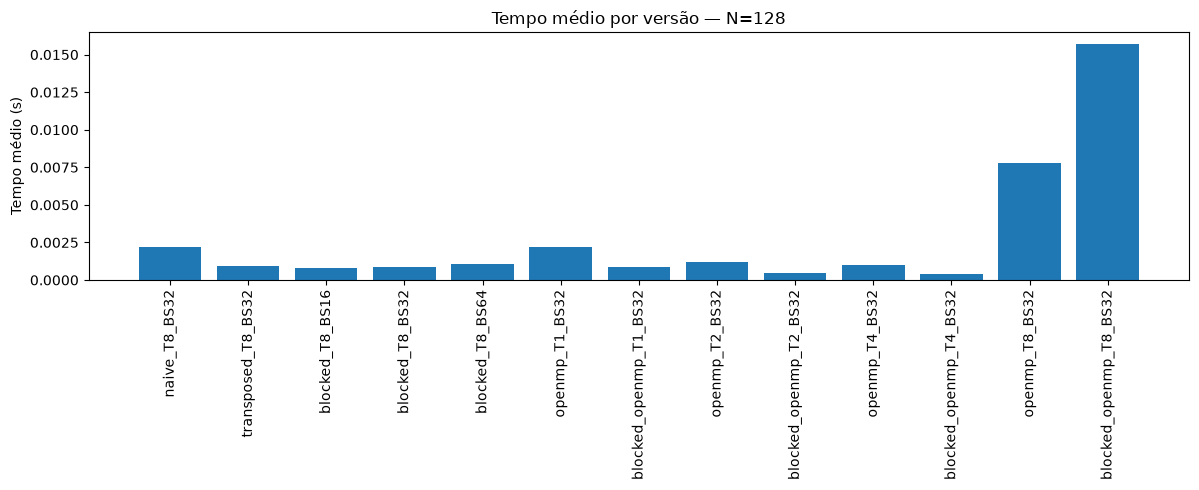

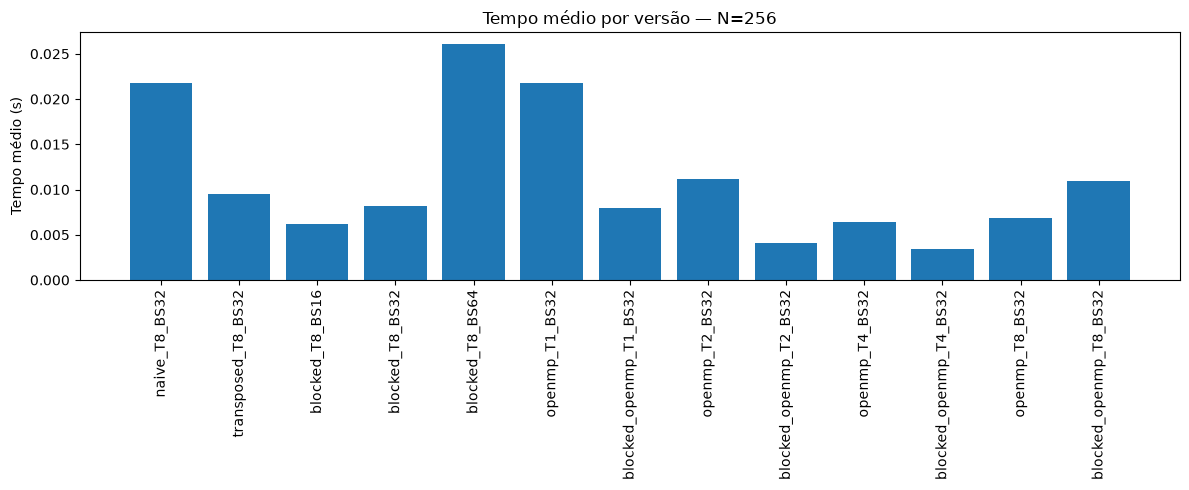

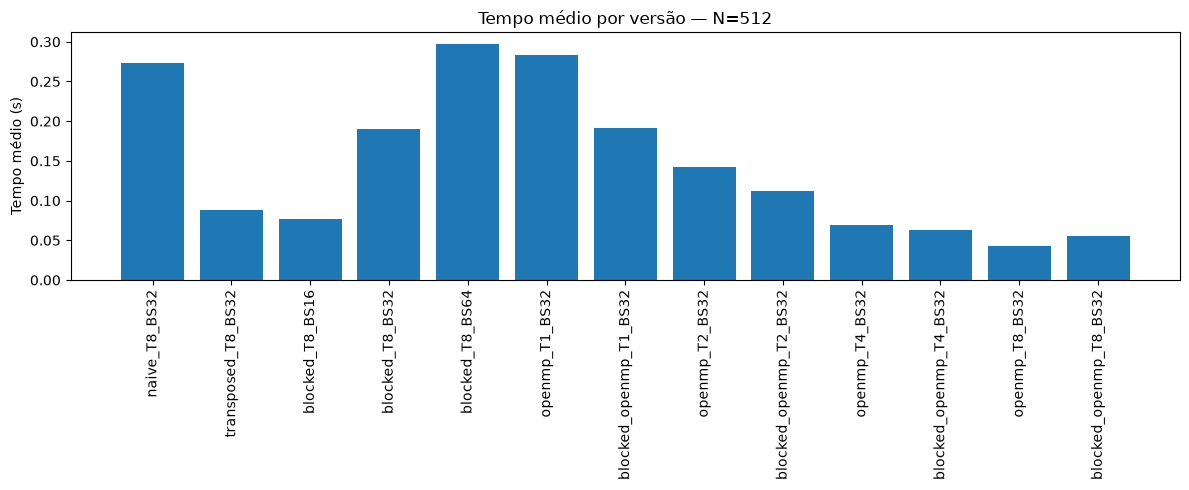

In [8]:
for N in sorted(cpu_results["N"].unique()):
    df = cpu_results[cpu_results["N"] == N].copy()
    labels = df["version"] + "_T" + df["threads"].astype(str) + "_BS" + df["BS"].astype(str)
    plt.figure(figsize=(12, 5))
    plt.bar(labels, df["avg_time_s"])
    plt.xticks(rotation=90)
    plt.ylabel("Tempo médio (s)")
    plt.title(f"Tempo médio por versão — N={N}")
    plt.tight_layout()
    plt.show()

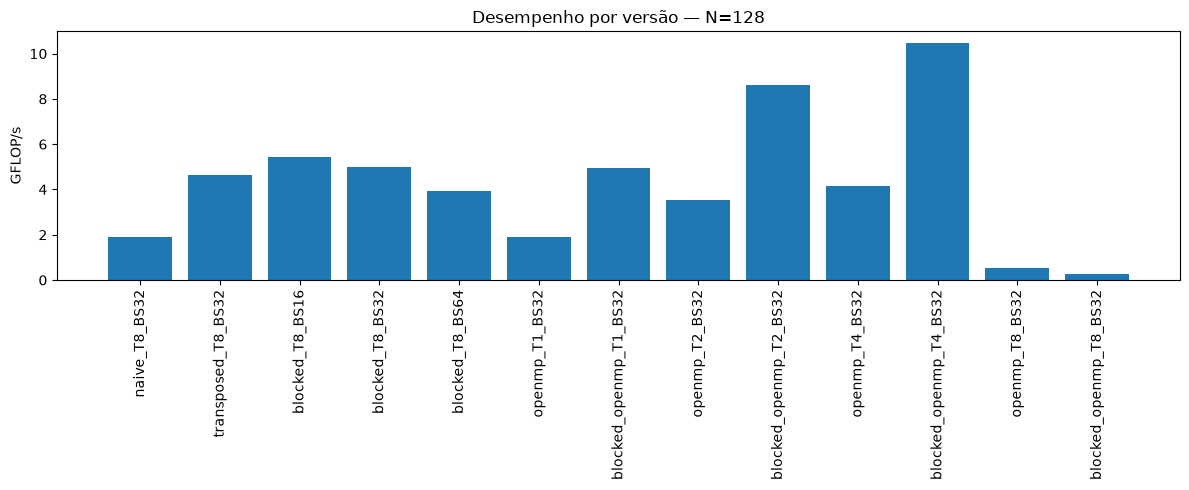

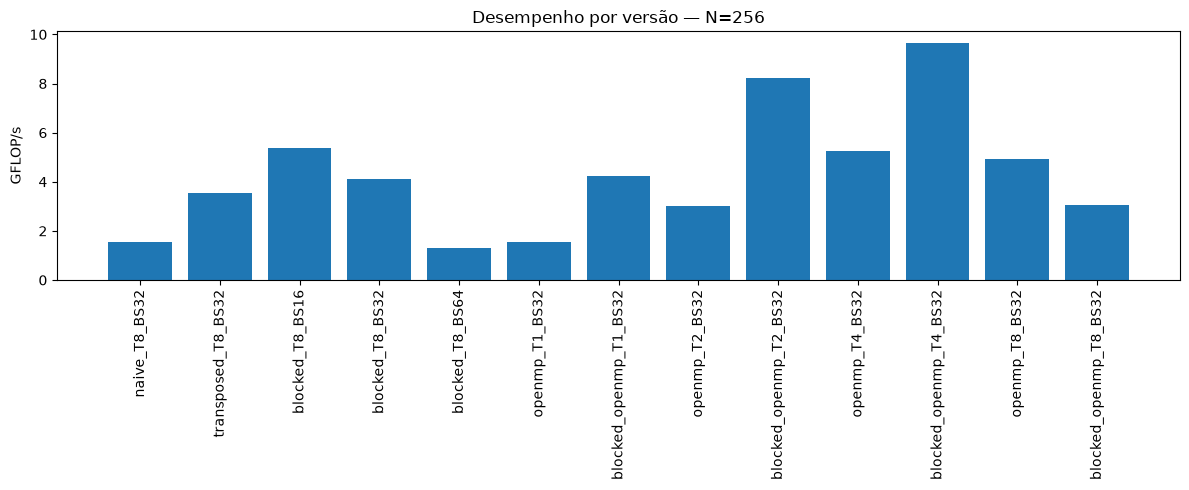

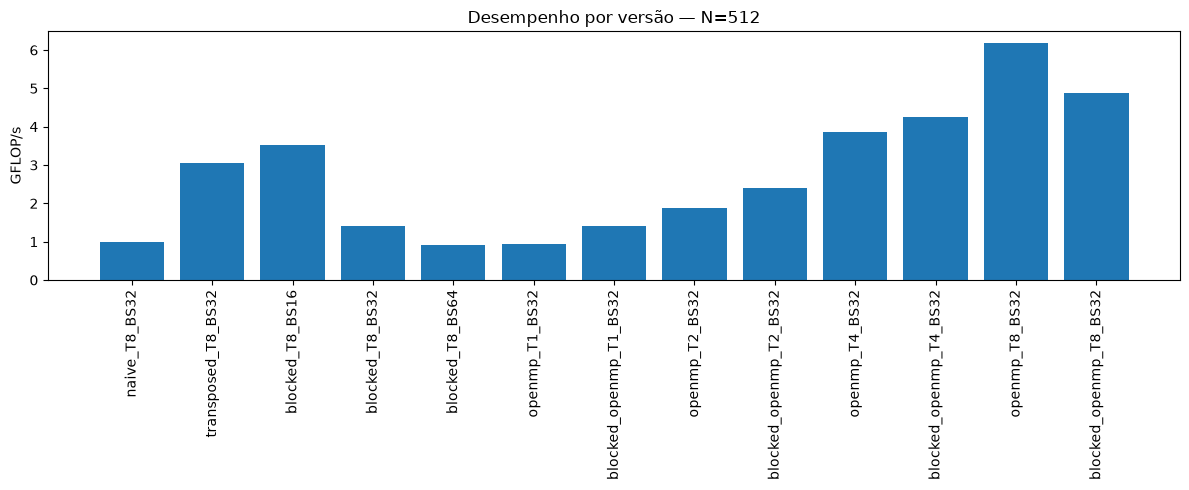

In [9]:
for N in sorted(cpu_results["N"].unique()):
    df = cpu_results[cpu_results["N"] == N].copy()
    labels = df["version"] + "_T" + df["threads"].astype(str) + "_BS" + df["BS"].astype(str)
    plt.figure(figsize=(12, 5))
    plt.bar(labels, df["GFLOPS"])
    plt.xticks(rotation=90)
    plt.ylabel("GFLOP/s")
    plt.title(f"Desempenho por versão — N={N}")
    plt.tight_layout()
    plt.show()

# Parte 5 — Código CUDA

A próxima célula deve-se implementar o programa em CUDA com duas versões:

- `cuda_naive`: uma thread calcula um elemento de C;
- `cuda_tiled`: usa memória compartilhada para reduzir acessos à memória global.

O programa mede separadamente:

1. tempo de cópia host → device;
2. tempo do kernel;
3. tempo de cópia device → host;
4. tempo total.

In [10]:
%%writefile gemm_cuda.cu
#include <stdio.h>
#include <stdlib.h>
#include <math.h>
#include <cuda_runtime.h>

#define TILE 16

static float rand_float() {
    return (float)rand() / (float)RAND_MAX;
}

static void fill_matrix(int N, float *M) {
    for (int i = 0; i < N*N; i++) M[i] = rand_float();
}

static void gemm_cpu_ref(int N, const float *A, const float *B, float *C) {
    for (int i = 0; i < N; i++) {
        for (int j = 0; j < N; j++) {
            float sum = 0.0f;
            for (int k = 0; k < N; k++) {
                sum += A[i*N + k] * B[k*N + j];
            }
            C[i*N + j] = sum;
        }
    }
}

static double max_abs_error(int N, const float *A, const float *B) {
    double err = 0.0;
    for (int i = 0; i < N*N; i++) {
        double e = fabs((double)A[i] - (double)B[i]);
        if (e > err) err = e;
    }
    return err;
}

__global__ void gemm_cuda_naive(int N, const float *A, const float *B, float *C) {
    /**
      TODO: implementar a versão CUDA.
    */
}

__global__ void gemm_cuda_tiled(int N, const float *A, const float *B, float *C) {

  /**
      TODO: implementar a versão CUDA com tiled.
    */
}

static void check_cuda(cudaError_t err, const char *msg) {
    if (err != cudaSuccess) {
        fprintf(stderr, "CUDA error at %s: %s\n", msg, cudaGetErrorString(err));
        exit(1);
    }
}

int main(int argc, char **argv) {
    if (argc < 4) {
        printf("Usage: %s <naive|tiled> <N> <repeats>\n", argv[0]);
        return 1;
    }

    const char *version = argv[1];
    int N = atoi(argv[2]);
    int repeats = atoi(argv[3]);
    size_t bytes = sizeof(float) * N * N;

    srand(0);
    float *h_A = (float*)malloc(bytes);
    float *h_B = (float*)malloc(bytes);
    float *h_C = (float*)malloc(bytes);
    float *h_ref = (float*)malloc(bytes);

    fill_matrix(N, h_A);
    fill_matrix(N, h_B);

    gemm_cpu_ref(N, h_A, h_B, h_ref);

    float *d_A, *d_B, *d_C;
    check_cuda(cudaMalloc(&d_A, bytes), "cudaMalloc A");
    check_cuda(cudaMalloc(&d_B, bytes), "cudaMalloc B");
    check_cuda(cudaMalloc(&d_C, bytes), "cudaMalloc C");

    cudaEvent_t start, stop;
    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    float h2d_ms_total = 0.0f;
    float kernel_ms_total = 0.0f;
    float d2h_ms_total = 0.0f;

    dim3 block(TILE, TILE);
    dim3 grid((N + TILE - 1) / TILE, (N + TILE - 1) / TILE);

    for (int r = 0; r < repeats; r++) {
        float ms;

        cudaEventRecord(start);
        check_cuda(cudaMemcpy(d_A, h_A, bytes, cudaMemcpyHostToDevice), "copy A H2D");
        check_cuda(cudaMemcpy(d_B, h_B, bytes, cudaMemcpyHostToDevice), "copy B H2D");
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        h2d_ms_total += ms;

        cudaEventRecord(start);
        if (version[0] == 'n') {
            gemm_cuda_naive<<<grid, block>>>(N, d_A, d_B, d_C);
        } else {
            gemm_cuda_tiled<<<grid, block>>>(N, d_A, d_B, d_C);
        }
        check_cuda(cudaGetLastError(), "kernel launch");
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        kernel_ms_total += ms;

        cudaEventRecord(start);
        check_cuda(cudaMemcpy(h_C, d_C, bytes, cudaMemcpyDeviceToHost), "copy C D2H");
        cudaEventRecord(stop);
        cudaEventSynchronize(stop);
        cudaEventElapsedTime(&ms, start, stop);
        d2h_ms_total += ms;
    }

    float h2d_ms = h2d_ms_total / repeats;
    float kernel_ms = kernel_ms_total / repeats;
    float d2h_ms = d2h_ms_total / repeats;
    float total_ms = h2d_ms + kernel_ms + d2h_ms;

    double kernel_gflops = (2.0 * N * N * N) / ((kernel_ms / 1000.0) * 1e9);
    double total_gflops = (2.0 * N * N * N) / ((total_ms / 1000.0) * 1e9);
    double err = max_abs_error(N, h_C, h_ref);

    printf("version,N,repeats,h2d_ms,kernel_ms,d2h_ms,total_ms,kernel_GFLOPS,total_GFLOPS,max_abs_error\n");
    printf("cuda_%s,%d,%d,%.6f,%.6f,%.6f,%.6f,%.6f,%.6f,%.8f\n",
           version, N, repeats, h2d_ms, kernel_ms, d2h_ms, total_ms,
           kernel_gflops, total_gflops, err);

    cudaFree(d_A); cudaFree(d_B); cudaFree(d_C);
    free(h_A); free(h_B); free(h_C); free(h_ref);
    return 0;
}

Overwriting gemm_cuda.cu


# Parte 6 — Compilação e execução CUDA

Caso esta célula falhe, verifique se o ambiente do Colab está com GPU ativada.

In [11]:
!nvcc gemm_cuda.cu -O3 -o gemm_cuda

/bin/bash: line 1: nvcc: command not found


# Parte 7 — Experimentos automatizados em GPU

A próxima célula executa as versões CUDA para vários tamanhos de matriz e salva os resultados em `gpu_results.csv`.

In [12]:
import subprocess
import pandas as pd
from io import StringIO

Ns = [128, 256, 512, 1024]
repeats = 5
rows = []

for N in Ns:
    for version in ["naive", "tiled"]:
        cmd = ["./gemm_cuda", version, str(N), str(repeats)]
        result = subprocess.run(cmd, capture_output=True, text=True)
        print(result.stdout)
        if result.returncode != 0:
            print(result.stderr)
            continue
        lines = result.stdout.strip().splitlines()
        if len(lines) >= 2:
            df = pd.read_csv(StringIO("\n".join(lines[-2:])))
            rows.append(df)

gpu_results = pd.concat(rows, ignore_index=True)
gpu_results.to_csv("gpu_results.csv", index=False)
gpu_results

FileNotFoundError: [Errno 2] No such file or directory: './gemm_cuda'

# Parte 8 — Gráficos GPU

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

gpu_results = pd.read_csv("gpu_results.csv")
gpu_results

In [ ]:
for N in sorted(gpu_results["N"].unique()):
    df = gpu_results[gpu_results["N"] == N]
    plt.figure(figsize=(8, 4))
    plt.bar(df["version"], df["kernel_ms"])
    plt.ylabel("Tempo do kernel (ms)")
    plt.title(f"Tempo do kernel CUDA — N={N}")
    plt.tight_layout()
    plt.show()

In [ ]:
for N in sorted(gpu_results["N"].unique()):
    df = gpu_results[gpu_results["N"] == N]
    plt.figure(figsize=(8, 4))
    plt.bar(df["version"], df["kernel_GFLOPS"])
    plt.ylabel("Kernel GFLOP/s")
    plt.title(f"Desempenho do kernel CUDA — N={N}")
    plt.tight_layout()
    plt.show()

# Parte 9 — Tabela final de comparação

Preencha a tabela final com os principais resultados obtidos.

| Versão | N | Tempo médio | GFLOP/s | Speedup | Eficiência | Observações |
|---|---:|---:|---:|---:|---:|---|
| CPU naive |  |  |  | 1,0 | 1,0 | Referência |
| CPU transposed |  |  |  |  |  | Localidade |
| CPU blocked |  |  |  |  |  | Cache |
| CPU OpenMP 2 threads |  |  |  |  |  | Threads |
| CPU OpenMP 4 threads |  |  |  |  |  | Threads |
| CUDA naive |  |  |  |  |  | Kernel simples |
| CUDA tiled |  |  |  |  |  | Memória compartilhada |

## Questões para discussão

Responda no relatório:

1. Por que a versão ingênua apresenta baixo desempenho?
2. O impacto da transposição de `B` foi significativo? Por quê?
3. Qual tamanho de bloco apresentou melhor desempenho? Por quê?
4. O compilador conseguiu vetorizar alguma parte do código? Use o relatório de vetorização como evidência.
5. O speedup com OpenMP foi próximo do ideal? Explique.
6. A eficiência diminuiu com mais threads? Por quê?
7. A GPU foi mais rápida considerando apenas o kernel?
8. A GPU foi mais rápida considerando o tempo total com cópias?
9. Qual foi a principal limitação observada: computação, memória, comunicação ou overhead?
10. Quais cuidados são necessários ao usar o Google Colab para avaliar desempenho?

# Parte 10 — Critérios de avaliação

## Implementação — 5 pontos

| Critério | Pontos |
|---|---:|
| Código sequencial correto e validação dos resultados | 1,0 |
| Otimização de localidade / transposição / blocagem | 1,0 |
| Análise de vetorização SIMD | 1,0 |
| Paralelização com OpenMP | 1,0 |
| Implementação CUDA com medição separada de cópia e kernel | 1,0 |

## Relatório — 5 pontos

| Critério | Pontos |
|---|---:|
| Metodologia experimental clara | 1,0 |
| Tabelas e gráficos bem apresentados | 1,0 |
| Cálculo correto de GFLOP/s, speedup e eficiência | 1,0 |
| Discussão técnica dos resultados | 1,5 |
| Conclusão crítica sobre limitações e trade-offs | 0,5 |